In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col


import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba

import numpy as np
from scipy.stats import t
from scipy.stats import norm
from scipy.stats import ttest_rel
from numpy.linalg import inv
import warnings

sns.set_style('whitegrid')
warnings. filterwarnings('ignore')

def convert_pvalue(test, pvalue):
    if pvalue <= 0.01:
        return "${:.3f}".format(test) + '^{***}$'
    elif pvalue <= 0.05:
        return "${:.3f}".format(test) + '^{**}$'
    elif pvalue <= 0.1:
        return "${:.3f}".format(test) + '^{*}$'
    return "${:.3f}$".format(test)

# Read Data

In [3]:
def fix_main_ocupation(x):
    if x not in ['Farming(crop+livestock)', 'Self employed off farm', 'Salaried employment']:
        return 'Other'
    else:
        return x
    
df_M_raw = pd.read_stata('../Data/drive-download-20231006T131216Z-001/CMS - Spouse Cleaned/Files/Husband Responses.dta')
df_M_raw = df_M_raw[(df_M_raw['A02_Sex'] == 'Male') & 
                    (df_M_raw['A04_Marital_status'] == 'married living with spouse/s') & 
                    (df_M_raw['A06_Relatn_hhd'].isin(['Household head', 'Spouse']))].reset_index(drop=True)

df_F_raw = pd.read_stata('../Data/drive-download-20231006T131216Z-001/Files/Wife Responses.dta')
df_F_raw = df_F_raw[(df_F_raw['A02_Sex'] == 'Female') &
                    (df_F_raw['A04_Marital_status'] == 'married living with spouse/s') & 
                    (df_F_raw['A06_Relatn_hhd'].isin(['Household head', 'Spouse']))].reset_index(drop=True)


df_allMF = pd.concat([df_M_raw, df_F_raw]).reset_index(drop=True)
both_responses = (df_allMF['HouseID'].value_counts()).to_frame()
both_responses = both_responses[both_responses['HouseID']== 2]
df_allMF = df_allMF[df_allMF['HouseID'].isin(both_responses.index)]
df_allMF = df_allMF.reset_index(drop=True)

df_allMF['A06_Relatn_hhd'] = df_allMF[f'A06_Relatn_hhd'].astype('category')# .cat.codes, 
df_allMF['A07_1_Main_occupatn'] = df_allMF[f'A07_1_Main_occupatn'].astype('category') 
df_allMF['A08_fam_lab_contributn'] = df_allMF['A08_fam_lab_contributn'].apply(lambda x: float(x.replace("%", ""))).astype(float)
df_allMF['A08_fam_lab_contributn'] = df_allMF['A08_fam_lab_contributn'].fillna(0)
df_allMF['A07_1_Main_occupatn'] = df_allMF['A07_1_Main_occupatn'].apply(fix_main_ocupation)
df_allMF['ZoneID'] = df_allMF['ZoneID'].astype(int)

df_M = df_allMF[df_allMF['A02_Sex'] == 'Male']
df_M = df_M.reset_index(drop=True)

df_H = df_allMF[df_allMF['A02_Sex'] == 'Male']
df_H = df_H.reset_index(drop=True)

df_F = df_allMF[df_allMF['A02_Sex'] == 'Female']
df_F = df_F.reset_index(drop=True)

df_H = pd.read_stata('../Data/drive-download-20231006T131216Z-001/CMS - Spouse Cleaned/Files/CMS Responses.dta')
df_H = df_H[df_H['HouseID'].isin(df_allMF['HouseID'].value_counts().keys())]
df_H = df_H.reset_index(drop=True)
df_H['A06_Relatn_hhd'] = df_H[f'A06_Relatn_hhd'].astype('category')# .cat.codes, 
df_H['A07_1_Main_occupatn'] = df_H[f'A07_1_Main_occupatn'].astype('category') 
df_H['A08_fam_lab_contributn'] = df_H['A08_fam_lab_contributn'].apply(lambda x: float(x.replace("%", ""))).astype(float)
df_H['A07_1_Main_occupatn'] = df_H['A07_1_Main_occupatn'].apply(fix_main_ocupation)
df_H['ZoneID'] = df_H['ZoneID'].astype(int)


# https://data.iita.org/dataset/the-cassava-monitoring-survey-cms-in-nigeria-household-and-plot-level-data
df_H_dna = pd.read_csv("../Data/CMS-raw/dna.csv")
houseIDs = df_M['HouseID'].value_counts().keys()
df_H_dna = df_H_dna[df_H_dna['HouseID'].isin(houseIDs)].groupby('HouseID', as_index=False).agg(
    {'StateID': 'min', 'adoption': ['sum', 'min']})
df_H_dna.columns = ['HouseID', 'ZoneID', 'Household_ICV', 'planted']
df_H_dna['ZoneID'] = (df_H_dna['ZoneID']/10).astype(int)#.tail()
df_H_dna.head()

,HouseID,ZoneID,Household_ICV,planted
0,112115,1,0,0
1,112213,1,1,1
2,112214,1,2,1
3,113113,1,0,0
4,113115,1,0,0


In [4]:
df_H[df_H['HouseID'] == 247111]['Men_In_House']

222    5.0
Name: Men_In_House, dtype: float64

In [5]:
# https://data.iita.org/dataset/the-cassava-monitoring-survey-cms-in-nigeria-household-and-plot-level-data
df_H_comp = pd.read_csv("../Data/CMS-raw/household_composition_all-regions.csv")
houseIDs = df_M['HouseID'].value_counts().keys()
df_H_comp = df_H_comp[df_H_comp['HouseID'].isin(houseIDs)]
df_H_comp['Men_In_House'] = df_H_comp['Sex'].apply(lambda x: 1 if x == 'Male' else 0)
df_H_comp['Women_In_House'] = df_H_comp['Sex'].apply(lambda x: 0 if x == 'Male' else 1)

df_H_comp = df_H_comp.groupby('HouseID').sum()[['Men_In_House', 'Women_In_House']].reset_index()
df_H_comp
#df_H_comp[df_H_comp['HouseID'] == 247111]['Sex']

,HouseID,Men_In_House,Women_In_House
0,112115,5,3
1,112213,2,2
2,112214,1,2
3,113113,4,2
4,113115,3,1
...,...,...,...
724,4316312,2,3
725,4317111,2,2
726,4318111,1,1
727,4318211,3,1


In [6]:
(df_H_comp['Men_In_House'] == df_M['Men_In_House']).value_counts()

True    729
Name: Men_In_House, dtype: int64

In [7]:
#df_H_comp = pd.read_csv("../Data/CMS-raw/household_composition_all-regions.csv")
originals = '../Data/drive-download-20231006T131216Z-001/CMS - Spouse Cleaned/Files/Data Cleaning - Individual Files/Original Files - Not Cleaned/CMS (entire database)/Files/'
df_H_comp = pd.read_stata(originals+'Householdcomposition_All regions.dta')
# df_H_comp = pd.read_stata(originals+'Cassava_Plot_All regions _dr tunji_Nike_var_coded.dta')
houseIDs = df_M['HouseID'].value_counts().keys()
df_H_comp = df_H_comp[(df_H_comp['HouseID'].isin(houseIDs)) ]#&# & 
                      #(df_H_comp['A06_Relatn_hhd'].isin(['Household head', 'Spouse']))]
df_H_comp['HouseID'].value_counts()
#df_H_comp[df_H_comp['HouseID'] == 128113]

df_H_comp[df_H_comp['HouseID'] == 247111]

,ZoneID,StateID,LgaID,LocalityID,EnumerationID,HouseID,Householdcomposition,A09_boys_12_and_below,A10_girls_12_and_below
1640,2.0,24.0,247.0,2471.0,24711.0,247111.0,How many do you have in your household,1.0,2.0


In [8]:
#df_H_comp = pd.read_csv("../Data/CMS-raw/household_composition_all-regions.csv")
spouse = '../Data/drive-download-20231006T131216Z-001/CMS - Spouse Cleaned/Files/Data Cleaning - Individual Files/Original Files - Not Cleaned/Spouse (wife)/'
#df_H_comp = pd.read_stata(spouse+'Household_composition_Spouse_All Regions.dta')
df_H_comp = pd.read_stata(spouse+'Cassava_Plot_Spouse_Funke_All Regions_Funke.dta')

houseIDs = df_M['HouseID'].value_counts().keys()
df_H_comp = df_H_comp[(df_H_comp['HouseID'].isin(houseIDs))] # & 
                      #(df_H_comp['A06_Relatn_hhd'].isin(['Household head', 'Spouse']))]


df_H_comp['HouseID'].value_counts()
df_H_comp[df_H_comp['HouseID'] == 128113].T
#df_H_comp[df_H_comp['HouseID'] == 247111].T

,433,434,435
ZoneID,1.0,1.0,1.0
StateID,12.0,12.0,12.0
LgaID,128.0,128.0,128.0
LocalityID,1281.0,1281.0,1281.0
EnumerationID,12811.0,12811.0,12811.0
HouseID,128113.0,128113.0,128113.0
CassavaPlotInformationID,2.0,3.0,1.0
D01_Fieldcode,Sula Yiow,Sula Mken,Sula Logo
D02_Field_locname,F2,F3,F1
D03_Plotcode,1.0,1.0,1.0


In [9]:
var = 'A05_Edu'
if str(df_M[f'{var}'].dtype) == 'category':# or str(df_M[f'{var}'].dtype == 'object'):
    ttest_MF = ttest_rel(df_M[f'{var}'].astype('category').cat.codes, 
                         df_F[f'{var}'].astype('category').cat.codes, 
                         nan_policy='omit')
else:
    #ttest_HM = ttest_rel(df_H[f'{var}'], df_M[f'{var}'], nan_policy='omit')
    #ttest_HF = ttest_rel(df_H[f'{var}'], df_F[f'{var}'], nan_policy='omit')
    ttest_MF = ttest_rel(df_M[f'{var}'], df_F[f'{var}'], nan_policy='omit')


print(var, 
      #convert_pvalue(df_H[f'{var}'].mean(), 1), " & ", 
      " & ", " & ", 
      convert_pvalue(df_M[f'{var}'].mean(), 1), " & ", 
      convert_pvalue(df_F[f'{var}'].mean(), 1), " & ", 
      #convert_pvalue(ttest_HM[0], ttest_HM[1]), " & ", 
      #convert_pvalue(ttest_HF[0], ttest_HF[1]), " & ", 
       " ", " & ", 
       " ", " & ", 
      convert_pvalue(ttest_MF[0], ttest_MF[1]), " \\\\ ")

A05_Edu  &   &  $9.342$  &  $8.029$  &     &     &  $6.858^{***}$  \\ 


# Empirical

In [10]:
dependent = ['Household_ICV', 'planted']

independent = ['Joint_Managed', 'Household_Plots', 'House_Cassava_Plot_TotalSize', 
               'Coop_Group_Member', 'Credit_Access', 'Joint_Total_Processing_Access',
               'Total_Household_Asset_Value', 'Total_Production_Asset_Value']

characteristic = ['ZoneID', 'A06_Relatn_hhd', 'A03_Age', 'A05_Edu',  
                  'A07_1_Main_occupatn', 'A08_fam_lab_contributn', 'Men_In_House', 
                  'Women_In_House', 'Kids']

for var in independent + characteristic:
    if str(df_M[f'{var}'].dtype) == 'category':# or str(df_M[f'{var}'].dtype == 'object'):
        ttest_MF = ttest_rel(df_M[f'{var}'].astype('category').cat.codes, 
                             df_F[f'{var}'].astype('category').cat.codes, 
                             nan_policy='omit')
        
        print("Cat", var, convert_pvalue(ttest_MF[0], ttest_MF[1]))
    else:
        ttest_MF = ttest_rel(df_M[f'{var}'], df_F[f'{var}'], nan_policy='omit')
        print("Num", var, convert_pvalue(ttest_MF[0], ttest_MF[1]))

Num Joint_Managed $-3.276^{***}$
Num Household_Plots $-1.181$
Num House_Cassava_Plot_TotalSize $6.487^{***}$
Cat Coop_Group_Member $-1.699^{*}$
Num Credit_Access $3.193^{***}$
Num Joint_Total_Processing_Access $8.775^{***}$
Num Total_Household_Asset_Value $3.965^{***}$
Num Total_Production_Asset_Value $0.888$
Num ZoneID $nan$
Cat A06_Relatn_hhd $-169.603^{***}$
Num A03_Age $28.879^{***}$
Num A05_Edu $6.858^{***}$


TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [11]:
df_M['A08_fam_lab_contributn'].isnull().value_counts()

False    729
Name: A08_fam_lab_contributn, dtype: int64

In [12]:
characteristic = ['ZoneID', 'A03_Age', 'A05_Edu', 'A08_fam_lab_contributn', 'A07_1_Main_occupatn']
df_characteristic = df_F[['HouseID'] + characteristic]
df_characteristic = df_characteristic.merge(df_M[['HouseID'] + characteristic[1:]], on='HouseID', suffixes=['_F', '_M'])
df_characteristic = pd.get_dummies(df_characteristic, 
                                   #columns = ['ZoneID', 'A07_1_Main_occupatn_F', 'A07_1_Main_occupatn_M'], 
                                   columns = ['ZoneID', 'A07_1_Main_occupatn_F', 'A07_1_Main_occupatn_M'],
                                   drop_first=True)#, 'A07_1_Main_occupatn_x', 'A07_1_Main_occupatn_y'])
df_characteristic.head()

,HouseID,A03_Age_F,A05_Edu_F,A08_fam_lab_contributn_F,A03_Age_M,A05_Edu_M,A08_fam_lab_contributn_M,ZoneID_2,ZoneID_3,ZoneID_4,A07_1_Main_occupatn_F_Other,A07_1_Main_occupatn_F_Salaried employment,A07_1_Main_occupatn_F_Self employed off farm,A07_1_Main_occupatn_M_Other,A07_1_Main_occupatn_M_Salaried employment,A07_1_Main_occupatn_M_Self employed off farm
0,112115.0,45.0,6.0,50.0,48.0,12.0,50.0,0,0,0,0,0,0,0,0,0
1,112213.0,60.0,16.0,50.0,60.0,14.0,100.0,0,0,0,0,1,0,0,0,0
2,112214.0,70.0,0.0,100.0,77.0,0.0,100.0,0,0,0,0,0,1,0,0,0
3,113113.0,47.0,7.0,100.0,65.0,7.0,100.0,0,0,0,0,0,0,0,0,0
4,113115.0,42.0,12.0,50.0,45.0,12.0,100.0,0,0,0,0,0,0,0,0,0


## Combination 8 
$u_F \neq 0,v_f = 0$ and $u_M = 0, v_M = 0$.

$$
 \begin{array}{ll}
      D(1,0,0,0) & = Y[V|u_F \neq 0] - Y^*   \\
      & = \beta \delta_F X^* + \delta_F\left(\gamma^{'} C + \epsilon \right) + \omega_M 
 \end{array}
 $$
 
 
Here, for the empirical analysis we will run:

$$
    Y_F - Y^* = \beta_8 X^* +  \gamma_{8}^{'} C + \epsilon_8 
$$

## Combination 10
$u_F \neq 0,v_f = 0$ and $u_M \neq 0, v_M = 0$.

$$
 \begin{array}{ll}
       D(1,0,1,0) & = Y[V|u_F \neq 0] - Y[V|u_M \neq 0]   \\
          & =\beta (\delta_F - \delta_M) X^* + (\delta_F - \delta_M) \left(\gamma^{'} C + \epsilon \right) + (\omega_F - \omega_M)
 \end{array}
 $$
 
 
Here, for the empirical analysis we will run:

$$
    Y_F - Y_M = \beta_{10} X^* + \gamma_{10}^{'} C + \epsilon_{10} 
$$

## Combination 12
$u_F \neq 0,v_f \neq 0$ and $u_M = 0, v_M = 0$.

$$
 \begin{array}{ll}
      D(1,0,0,0) & = Y[V|u_F \neq 0] - Y^*   \\
       & = \beta  \delta_F X^* + \beta \alpha_F (1 + \delta_F) X^* + \beta \xi_F (1+\delta_F) \\
       & \hphantom{-} + \delta_F \left( \gamma^{'} C + \epsilon \right)  + \omega_F 
 \end{array}
 $$
 
 
Here, for the empirical analysis we will run:

$$
     Y_F - Y^* = \beta_{12\_1} X^* + \beta_{12\_2} X_F +   \gamma_{12}^{'} C + \epsilon_{12} 
$$

## Combination 14
$u_F \neq 0,v_f \neq 0$ and $u_M \neq 0, v_M = 0$.

$$
 \begin{array}{ll}
       D(1,1,1,0) & =  Y[V|u_F \neq 0, v_F \neq 0] - Y[V|u_M \neq 0]  \\
          & = \beta (\delta_F - \delta_M) X^* + \beta \alpha_F (1+\delta_F)  X^* + \beta (1+\delta_F) \xi_F + \\
          & \hphantom{-} (\delta_F - \delta_M)\left(\gamma^{'} C + \epsilon\right) + (\omega_F - \omega_M) \\
 \end{array}
 $$
 
 
Here, for the empirical analysis we will run:

$$
     Y_F - Y_M = \beta_{14\_1} X^* + \beta_{14\_2} X_F +   \gamma_{14}^{'}C + \epsilon_{14}  
$$

In [13]:
def clean_table(summary_str):
    summary_str = summary_str.split('\n')
    # Find dummy indexes
    dummy_idx = []
    df_characteristics_tmp = df_characteristic.drop(['ZoneID_2', 'ZoneID_3', 'ZoneID_4'], axis=1)

    for i, li in enumerate(summary_str):
        if li.split('&')[0].strip().replace('\\', '') in df_characteristics_tmp.keys():
            #print(i)
            dummy_idx.append(i)
            dummy_idx.append(i + 1)

    # Print summary avoiding dummy indexes
    for i, li in enumerate(summary_str):
        if i not in dummy_idx:
            print(li)

In [14]:
var1 = 'Household_Plots'
df_tmp = df_F[['HouseID', 'planted']]
df_tmp = df_tmp.merge(df_H_dna[['HouseID', 'planted']], on='HouseID', suffixes=['_F', '_H'])
df_tmp = df_tmp.merge(df_H[['HouseID', var1]], on='HouseID')
df_tmp = df_tmp.merge(df_characteristic, on='HouseID')

Y = df_tmp['planted_F'] - df_tmp['planted_H']
X = df_tmp[df_tmp.columns[3:]]
X = sm.add_constant(pd.get_dummies(X), prepend=False)
model_8_1 = sm.OLS(Y,X)
results_8_1 = model_8_1.fit(cov_type='HC0')


df_tmp = df_F[['HouseID', 'Household_ICV']]
df_tmp = df_tmp.merge(df_H_dna[['HouseID', 'Household_ICV']], on='HouseID', suffixes=['_F', '_M'])
df_tmp = df_tmp.merge(df_H[['HouseID', var1]], on='HouseID')
df_tmp = df_tmp.merge(df_characteristic, on='HouseID')

Y = df_tmp['Household_ICV_F'] - df_tmp['Household_ICV_M']
X = df_tmp[df_tmp.columns[3:]]
X = sm.add_constant(pd.get_dummies(X), prepend=False)
model_10_1 = sm.OLS(Y,X)
results_10_1 = model_10_1.fit(cov_type='HC0')

############################################################################################################

var2 = 'Joint_Total_Processing_Access'

df_tmp = df_F[['HouseID', 'planted']]
df_tmp = df_tmp.merge(df_H_dna[['HouseID', 'planted']], on='HouseID', suffixes=['_F', '_H'])
df_tmp = df_tmp.merge(df_F[['HouseID', var2]], on='HouseID')
df_tmp = df_tmp.merge(df_H[['HouseID', var2]], on='HouseID', suffixes=['_F', '_H'])
df_tmp = df_tmp.merge(df_characteristic, on='HouseID')


Y = df_tmp['planted_F'] - df_tmp['planted_H']
X = df_tmp[df_tmp.columns[3:]]
X = sm.add_constant(pd.get_dummies(X), prepend=False)

model_12_1 = sm.OLS(Y,X)
results_12_1 = model_12_1.fit(cov_type='HC0')


df_tmp = df_F[['HouseID', 'Household_ICV']]
df_tmp = df_tmp.merge(df_H_dna[['HouseID', 'Household_ICV']], on='HouseID', suffixes=['_F', '_M'])
df_tmp = df_tmp.merge(df_F[['HouseID', var2]], on='HouseID')
df_tmp = df_tmp.merge(df_H[['HouseID', var2]], on='HouseID', suffixes=['_F', '_H'])
df_tmp = df_tmp.merge(df_characteristic, on='HouseID')

Y = df_tmp['Household_ICV_F'] - df_tmp['Household_ICV_M']
X = df_tmp[df_tmp.columns[3:]]
X = sm.add_constant(pd.get_dummies(X), prepend=False)
model_14_1 = sm.OLS(Y,X)
results_14_1 = model_14_1.fit(cov_type='HC0')

all_var =['Household_Plots', 
          var2 + "_F", var2 + "_H",
          'ZoneID_2', 'ZoneID_3', 'ZoneID_4',
          'const']

summary_str = summary_col([results_8_1, results_10_1, results_12_1, results_14_1], 
                  stars=True,
                  model_names=['I', 'II', 'III', 'IV'],
                  float_format='%.3f',
                  info_dict={
                      'N':lambda x: "{0:d}".format(int(x.nobs))
                  },
                  regressor_order=all_var).as_latex()

clean_table(summary_str)

\begin{table}
\caption{}
\label{}
\begin{center}
\begin{tabular}{lllll}
\hline
                                                  & I         & II       & III       & IV         \\
\hline
Household\_Plots                                  & 0.056***  & -0.332** &           &            \\
                                                  & (0.021)   & (0.133)  &           &            \\
Joint\_Total\_Processing\_Access\_F               &           &          & 0.026     & 0.071      \\
                                                  &           &          & (0.018)   & (0.058)    \\
Joint\_Total\_Processing\_Access\_H               &           &          & -0.027    & -0.094*    \\
                                                  &           &          & (0.017)   & (0.053)    \\
ZoneID\_2                                         & -0.153**  & 0.099    & -0.143*   & 0.099      \\
                                                  & (0.071)   & (0.213)  & (0.075)   & (0.218)    \\
ZoneI

In [15]:
#var1 = 'Joint_Credit'
var1 = 'Women_Owned_HHAsset_Value'
#var1 = 'Female_Credit_Only'

df_tmp = df_F[['HouseID', 'planted']]
df_tmp = df_tmp.merge(df_H_dna[['HouseID', 'planted']], on='HouseID', suffixes=['_F', '_H'])
df_tmp = df_tmp.merge(df_H[['HouseID', var1]], on='HouseID')
df_tmp = df_tmp.merge(df_characteristic, on='HouseID')

Y = df_tmp['planted_F'] - df_tmp['planted_H']
X = df_tmp[df_tmp.columns[3:]]
X = sm.add_constant(pd.get_dummies(X), prepend=False)
model_8_1 = sm.OLS(Y,X)
results_8_1 = model_8_1.fit(cov_type='HC0')


df_tmp = df_F[['HouseID', 'Household_ICV']]
df_tmp = df_tmp.merge(df_H_dna[['HouseID', 'Household_ICV']], on='HouseID', suffixes=['_F', '_M'])
df_tmp = df_tmp.merge(df_H[['HouseID', var1]], on='HouseID')
df_tmp = df_tmp.merge(df_characteristic, on='HouseID')

Y = df_tmp['Household_ICV_F'] - df_tmp['Household_ICV_M']
X = df_tmp[df_tmp.columns[3:]]
X = sm.add_constant(pd.get_dummies(X), prepend=False)
model_10_1 = sm.OLS(Y,X)
results_10_1 = model_10_1.fit(cov_type='HC0')

############################################################################################################

#var2 = 'Credit_Access'
var2 = 'Male_Owned_HHAsset_Value'
#var2='Male_Credit_Only'

df_tmp = df_F[['HouseID', 'planted']]
df_tmp = df_tmp.merge(df_H_dna[['HouseID', 'planted']], on='HouseID', suffixes=['_F', '_H'])
df_tmp = df_tmp.merge(df_F[['HouseID', var2]], on='HouseID')
df_tmp = df_tmp.merge(df_H[['HouseID', var2]], on='HouseID', suffixes=['_F', '_H'])
df_tmp = df_tmp.merge(df_characteristic, on='HouseID')


Y = df_tmp['planted_F'] - df_tmp['planted_H']
X = df_tmp[df_tmp.columns[3:]]
X = sm.add_constant(pd.get_dummies(X), prepend=False)

model_12_1 = sm.OLS(Y,X)
results_12_1 = model_12_1.fit(cov_type='HC0')


df_tmp = df_F[['HouseID', 'Household_ICV']]
df_tmp = df_tmp.merge(df_H_dna[['HouseID', 'Household_ICV']], on='HouseID', suffixes=['_F', '_M'])
df_tmp = df_tmp.merge(df_F[['HouseID', var2]], on='HouseID')
df_tmp = df_tmp.merge(df_H[['HouseID', var2]], on='HouseID', suffixes=['_F', '_H'])
df_tmp = df_tmp.merge(df_characteristic, on='HouseID')

Y = df_tmp['Household_ICV_F'] - df_tmp['Household_ICV_M']
X = df_tmp[df_tmp.columns[3:]]
X = sm.add_constant(pd.get_dummies(X), prepend=False)
model_14_1 = sm.OLS(Y,X)
results_14_1 = model_14_1.fit(cov_type='HC0')

summary_str = summary_col([results_8_1, results_10_1, results_12_1, results_14_1], 
                  stars=True,
                  model_names=['I', 'II', 'III', 'IV'],
                  float_format='%.3f',
                  info_dict={
                      'N':lambda x: "{0:d}".format(int(x.nobs))
                  },
                  regressor_order=[var1, 
                                   var2 + "_F", var2 + "_H",
                                  'ZoneID_2', 'ZoneID_3', 'ZoneID_4',
                                  'const']).as_latex()

clean_table(summary_str)

\begin{table}
\caption{}
\label{}
\begin{center}
\begin{tabular}{lllll}
\hline
                                                  & I        & II        & III      & IV         \\
\hline
Women\_Owned\_HHAsset\_Value                      & 0.000**  & 0.000***  &          &            \\
                                                  & (0.000)  & (0.000)   &          &            \\
Male\_Owned\_HHAsset\_Value\_F                    &          &           & 0.000    & 0.000      \\
                                                  &          &           & (0.000)  & (0.000)    \\
Male\_Owned\_HHAsset\_Value\_H                    &          &           & 0.000    & 0.000      \\
                                                  &          &           & (0.000)  & (0.000)    \\
ZoneID\_2                                         & -0.147** & 0.066     & -0.147** & 0.070      \\
                                                  & (0.071)  & (0.219)   & (0.071)  & (0.219)    \\
ZoneID\_3     

In [16]:
var1 = 'Women__Production_Value'
var2 = 'Male__Production_Value'
var3 = 'Total_Production_Asset_Value'

results_8 = []
results_10 = []
for var in [var1, var2, var3]:
    df_tmp = df_F[['HouseID', 'planted']]
    df_tmp = df_tmp.merge(df_H_dna[['HouseID', 'planted']], on='HouseID', suffixes=['_F', '_H'])
    df_tmp = df_tmp.merge(df_H[['HouseID', var]], on='HouseID')
    df_tmp = df_tmp.merge(df_characteristic, on='HouseID')

    Y = df_tmp['planted_F'] - df_tmp['planted_H']
    X = df_tmp[df_tmp.columns[3:]]
    X = sm.add_constant(pd.get_dummies(X), prepend=False)
    model_8_1 = sm.OLS(Y,X)
    results_8_1 = model_8_1.fit(cov_type='HC0')
    results_8.append(results_8_1)

    df_tmp = df_F[['HouseID', 'Household_ICV']]
    df_tmp = df_tmp.merge(df_H_dna[['HouseID', 'Household_ICV']], on='HouseID', suffixes=['_F', '_M'])
    df_tmp = df_tmp.merge(df_H[['HouseID', var]], on='HouseID')
    df_tmp = df_tmp.merge(df_characteristic, on='HouseID')

    Y = df_tmp['Household_ICV_F'] - df_tmp['Household_ICV_M']
    X = df_tmp[df_tmp.columns[3:]]
    X = sm.add_constant(pd.get_dummies(X), prepend=False)
    model_10_1 = sm.OLS(Y,X)
    results_10_1 = model_10_1.fit(cov_type='HC0')
    results_10.append(results_10_1)


summary_str = summary_col([results_8[0], results_10[0], results_8[1], results_10[1], results_8[2], results_10[2]], 
                  stars=True,
                  model_names=['I', 'II', 'III', 'IV', 'V', "VI"],
                  float_format='%.3f',
                  info_dict={
                      'N':lambda x: "{0:d}".format(int(x.nobs))
                  },
                  regressor_order=[var1, var2, var3,
                                  'ZoneID_2', 'ZoneID_3', 'ZoneID_4',
                                  'const']).as_latex()

clean_table(summary_str)

\begin{table}
\caption{}
\label{}
\begin{center}
\begin{tabular}{lllllll}
\hline
                                                  & I        & II        & III      & IV        & V        & VI         \\
\hline
Women\_\_Production\_Value                        & 0.000    & -0.000    &          &           &          &            \\
                                                  & (0.000)  & (0.000)   &          &           &          &            \\
Male\_\_Production\_Value                         &          &           & -0.000   & 0.000     &          &            \\
                                                  &          &           & (0.000)  & (0.000)   &          &            \\
Total\_Production\_Asset\_Value                   &          &           &          &           & -0.000   & 0.000      \\
                                                  &          &           &          &           & (0.000)  & (0.000)    \\
ZoneID\_2                                         &

In [17]:
var1 = 'Female_Managed'
var2 = 'Male_Managed'
var3 = 'Joint_Managed'

results_12 = []
results_14 = []
for var in [var1, var2, var3]:
    df_tmp = df_F[['HouseID', 'planted']]
    df_tmp = df_tmp.merge(df_H_dna[['HouseID', 'planted']], on='HouseID', suffixes=['_F', '_H'])
    df_tmp = df_tmp.merge(df_F[['HouseID', var]], on='HouseID')
    df_tmp = df_tmp.merge(df_H[['HouseID', var]], on='HouseID', suffixes=['_F', '_H'])
    df_tmp = df_tmp.merge(df_characteristic, on='HouseID')


    Y = df_tmp['planted_F'] - df_tmp['planted_H']
    X = df_tmp[df_tmp.columns[3:]]
    X = sm.add_constant(pd.get_dummies(X), prepend=False)

    model_12_1 = sm.OLS(Y,X)
    results_12_1 = model_12_1.fit(cov_type='HC0')
    results_12.append(results_12_1)

    df_tmp = df_F[['HouseID', 'Household_ICV']]
    df_tmp = df_tmp.merge(df_H_dna[['HouseID', 'Household_ICV']], on='HouseID', suffixes=['_F', '_M'])
    df_tmp = df_tmp.merge(df_F[['HouseID', var]], on='HouseID')
    df_tmp = df_tmp.merge(df_H[['HouseID', var]], on='HouseID', suffixes=['_F', '_H'])
    df_tmp = df_tmp.merge(df_characteristic, on='HouseID')

    Y = df_tmp['Household_ICV_F'] - df_tmp['Household_ICV_M']
    X = df_tmp[df_tmp.columns[3:]]
    X = sm.add_constant(pd.get_dummies(X), prepend=False)
    model_14_1 = sm.OLS(Y,X)
    results_14_1 = model_14_1.fit(cov_type='HC0')
    results_14.append(results_14_1)



summary_str = summary_col([results_12[0], results_14[0], results_12[1], results_14[1], results_12[2], results_14[2]], 
                  stars=True,
                  model_names=['I', 'II', 'III', 'IV', 'V', "VI"],
                  float_format='%.3f',
                  info_dict={
                      'N':lambda x: "{0:d}".format(int(x.nobs))
                  },
                  regressor_order=[var1 + "_F", var1 + "_H", 
                                   var2 + "_F", var2 + "_H", 
                                   var3 + "_F", var3 + "_H"]).as_latex()

clean_table(summary_str)

\begin{table}
\caption{}
\label{}
\begin{center}
\begin{tabular}{lllllll}
\hline
                                                  & I         & II        & III      & IV        & V         & VI         \\
\hline
Female\_Managed\_F                                & 0.045     & 0.163     &          &           &           &            \\
                                                  & (0.031)   & (0.194)   &          &           &           &            \\
Female\_Managed\_H                                & -0.011    & -0.519    &          &           &           &            \\
                                                  & (0.038)   & (0.443)   &          &           &           &            \\
Male\_Managed\_F                                  &           &           & 0.015    & 0.113     &           &            \\
                                                  &           &           & (0.023)  & (0.087)   &           &            \\
Male\_Managed\_H                     

In [18]:
var1 = 'Household_Plots'
df_characteristics_tmp = df_characteristic.drop(['ZoneID_2', 'ZoneID_3', 'ZoneID_4'], axis=1)
for zone in df_F['ZoneID'].unique():
    print("ZONE", zone)
    df_F_tmp = df_F[df_F['ZoneID'] == zone]
    df_M_tmp = df_M[df_M['ZoneID'] == zone]
    df_H_tmp = df_F[df_H['ZoneID'] == zone]
    df_H_dna_tmp = df_H_dna[df_H_dna['ZoneID'] == zone]
    
    df_tmp = df_F_tmp[['HouseID', 'planted']]
    df_tmp = df_tmp.merge(df_H_dna_tmp[['HouseID', 'planted']], on='HouseID', suffixes=['_F', '_H'])
    df_tmp = df_tmp.merge(df_H_tmp[['HouseID', var1]], on='HouseID')
    df_tmp = df_tmp.merge(df_characteristics_tmp, on='HouseID')

    Y = df_tmp['planted_F'] - df_tmp['planted_H']
    X = df_tmp[df_tmp.columns[3:]]
    X = sm.add_constant(pd.get_dummies(X), prepend=False)
    model_8_1 = sm.OLS(Y,X)
    results_8_1 = model_8_1.fit(cov_type='HC0')


    df_tmp = df_F_tmp[['HouseID', 'Household_ICV']]
    df_tmp = df_tmp.merge(df_H_dna_tmp[['HouseID', 'Household_ICV']], on='HouseID', suffixes=['_F', '_M'])
    df_tmp = df_tmp.merge(df_H_tmp[['HouseID', var1]], on='HouseID')
    df_tmp = df_tmp.merge(df_characteristics_tmp, on='HouseID')

    Y = df_tmp['Household_ICV_F'] - df_tmp['Household_ICV_M']
    X = df_tmp[df_tmp.columns[3:]]
    X = sm.add_constant(pd.get_dummies(X), prepend=False)
    model_10_1 = sm.OLS(Y,X)
    results_10_1 = model_10_1.fit(cov_type='HC0')

    ############################################################################################################

    var2 = 'Joint_Managed'

    df_tmp = df_F_tmp[['HouseID', 'planted']]
    df_tmp = df_tmp.merge(df_H_dna_tmp[['HouseID', 'planted']], on='HouseID', suffixes=['_F', '_H'])
    df_tmp = df_tmp.merge(df_F_tmp[['HouseID', var2]], on='HouseID')
    df_tmp = df_tmp.merge(df_H_tmp[['HouseID', var2]], on='HouseID', suffixes=['_F', '_H'])
    df_tmp = df_tmp.merge(df_characteristics_tmp, on='HouseID')


    Y = df_tmp['planted_F'] - df_tmp['planted_H']
    X = df_tmp[df_tmp.columns[3:]]
    X = sm.add_constant(pd.get_dummies(X), prepend=False)

    model_12_1 = sm.OLS(Y,X)
    results_12_1 = model_12_1.fit(cov_type='HC0')


    df_tmp = df_F_tmp[['HouseID', 'Household_ICV']]
    df_tmp = df_tmp.merge(df_H_dna_tmp[['HouseID', 'Household_ICV']], on='HouseID', suffixes=['_F', '_M'])
    df_tmp = df_tmp.merge(df_F_tmp[['HouseID', var2]], on='HouseID')
    df_tmp = df_tmp.merge(df_H_tmp[['HouseID', var2]], on='HouseID', suffixes=['_F', '_H'])
    df_tmp = df_tmp.merge(df_characteristics_tmp, on='HouseID')

    Y = df_tmp['Household_ICV_F'] - df_tmp['Household_ICV_M']
    X = df_tmp[df_tmp.columns[3:]]
    X = sm.add_constant(pd.get_dummies(X), prepend=False)
    model_14_1 = sm.OLS(Y,X)
    results_14_1 = model_14_1.fit(cov_type='HC0')

    summary_str  = summary_col([results_8_1, results_10_1, results_12_1, results_14_1], 
                      stars=True,
                      model_names=['I', 'II', 'III', 'IV'],
                      float_format='%.3f',
                      info_dict={
                          'N':lambda x: "{0:d}".format(int(x.nobs))
                      },
                      regressor_order=['Household_Plots', var2 + "_F", var2 + "_H"]).as_latex()
    
    clean_table(summary_str)

ZONE 1
\begin{table}
\caption{}
\label{}
\begin{center}
\begin{tabular}{lllll}
\hline
                                                  & I        & II       & III     & IV        \\
\hline
Household\_Plots                                  & 0.113*** & 0.540*** &         &           \\
                                                  & (0.040)  & (0.138)  &         &           \\
Joint\_Managed\_F                                 &          &          & 0.037** & 0.158**   \\
                                                  &          &          & (0.018) & (0.067)   \\
Joint\_Managed\_H                                 &          &          & 0.037** & 0.158**   \\
                                                  &          &          & (0.018) & (0.067)   \\
const                                             & 0.167    & -2.339** & 0.250   & -1.923*   \\
                                                  & (0.418)  & (1.072)  & (0.428) & (1.117)   \\
R-squared                         

# Yes/No ICV by Zone

ZONE 1
ZONE 2
ZONE 3
ZONE 4
ZONE 1
ZONE 2
ZONE 3
ZONE 4


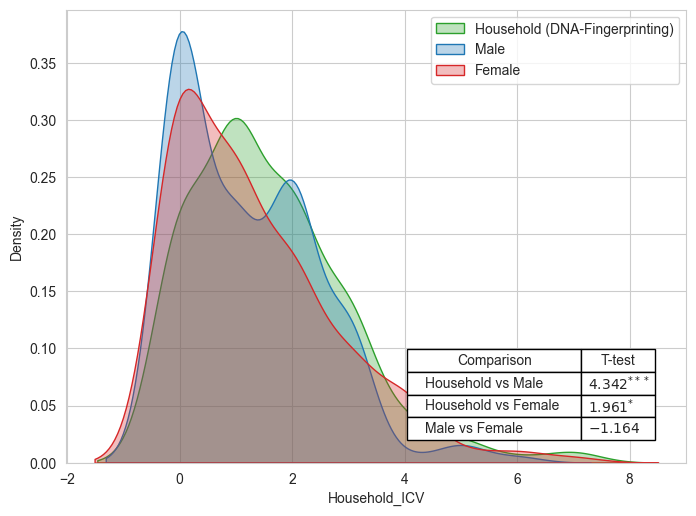

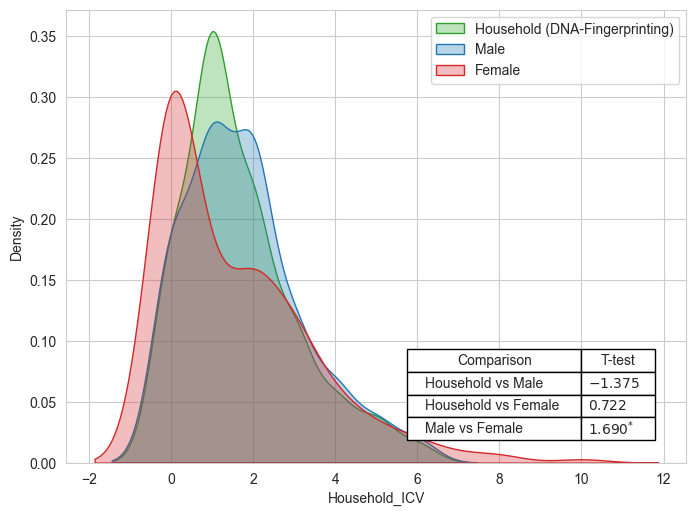

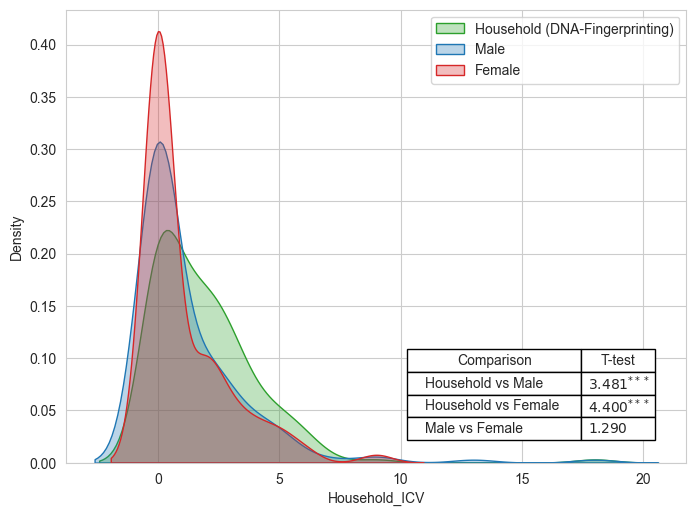

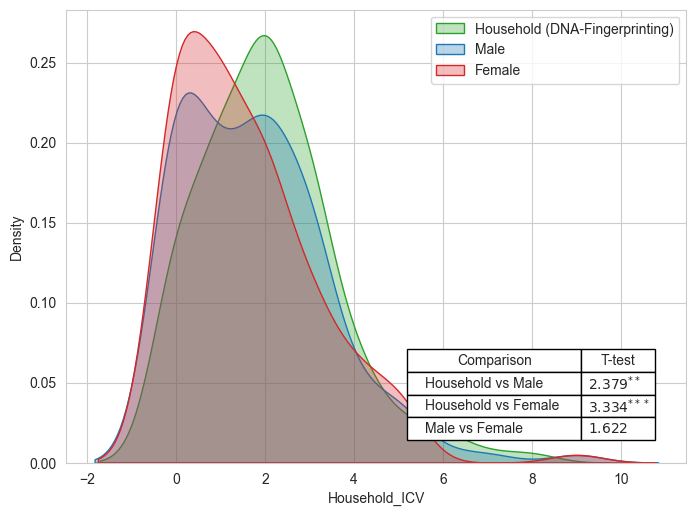

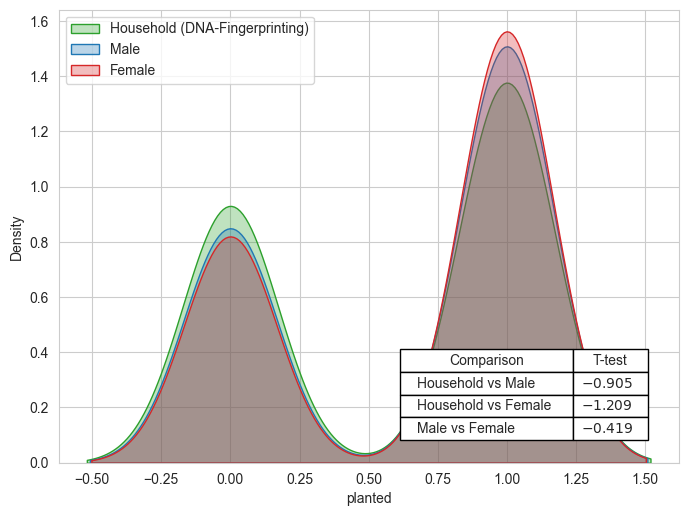

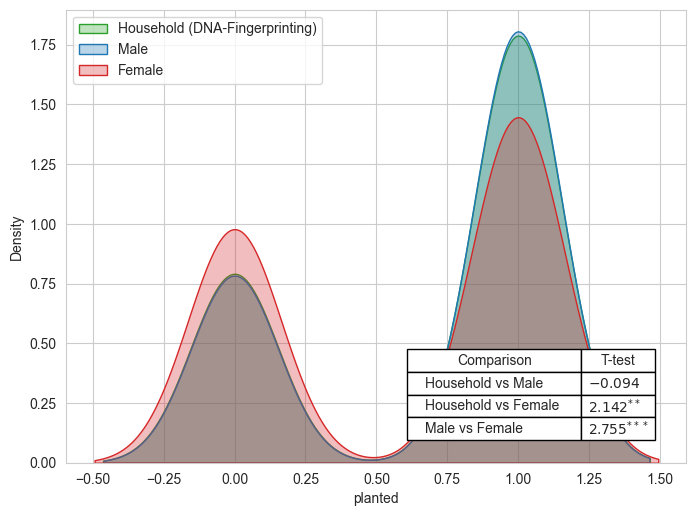

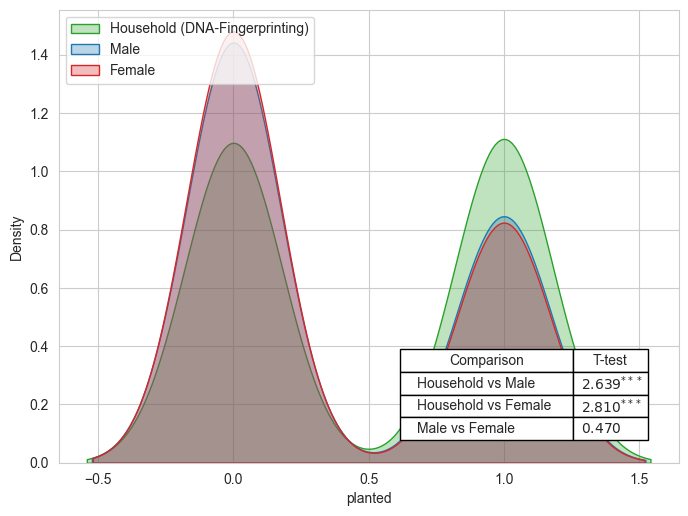

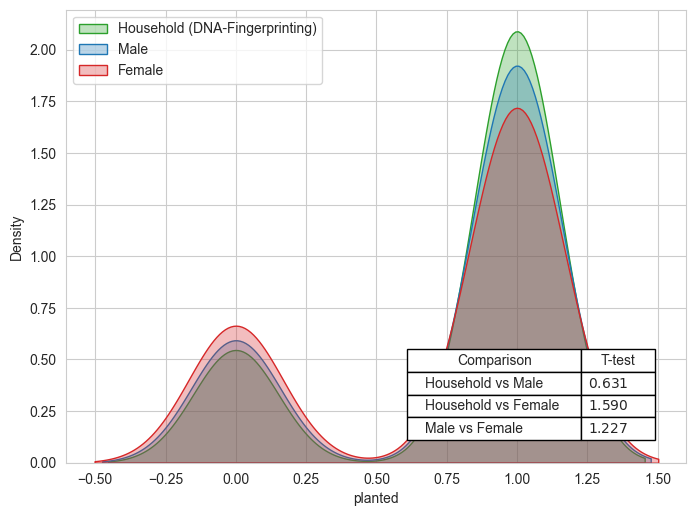

In [19]:
for index, var in enumerate(['Household_ICV', 'planted']):
    for zone in df_F['ZoneID'].unique():
        print("ZONE", zone)
        fig1, ax1 = plt.subplots(dpi=100, figsize=(8, 6))
    
        df_F_tmp = df_F[df_F['ZoneID'] == zone]
        df_M_tmp = df_M[df_M['ZoneID'] == zone]
        df_H_tmp = df_F[df_H['ZoneID'] == zone]
        df_H_dna_tmp = df_H_dna[df_H_dna['ZoneID'] == zone]

        ttest_HM = ttest_rel(df_H_dna_tmp[f'{var}'], df_M_tmp[f'{var}'], nan_policy='omit')
        ttest_HF = ttest_rel(df_H_dna_tmp[f'{var}'], df_F_tmp[f'{var}'], nan_policy='omit')
        ttest_MF = ttest_rel(df_M_tmp[f'{var}'], df_F_tmp[f'{var}'], nan_policy='omit')

        data = []
        data.append(['Household vs Male', convert_pvalue(ttest_HM[0], ttest_HM[1])])
        data.append(['Household vs Female', convert_pvalue(ttest_HF[0], ttest_HF[1])])
        data.append(['Male vs Female', convert_pvalue(ttest_MF[0], ttest_MF[1])])

        df_ttest = pd.DataFrame(data, columns = ['Comparison', 'T-test'])

        sns.kdeplot(df_H_dna_tmp[var], ax = ax1, fill=True, color="C2", label ="Household (DNA-Fingerprinting)",  alpha=0.3)
        sns.kdeplot(df_M_tmp[var], ax = ax1, fill=True, color="C0", label ="Male",  alpha=0.3)
        sns.kdeplot(df_F_tmp[var], ax = ax1, fill=True, color="C3", label ="Female",  alpha=0.3)
        ax1.set_xlabel(var)

        ax1.table(cellText=df_ttest.values, colLabels=df_ttest.columns, 
                  cellLoc='left', colWidths=[0.7, 0.3], bbox = (0.55, 0.05, 0.4, 0.2), loc='lower right', zorder=10)
        ax1.legend(loc=index+1)
        # ax1.set_title(labels[index])

        fig1.savefig(f"../Output/Figures/{var}_Zone{zone}.png", dpi=100, bbox_inches='tight' )

In [20]:
import numpy as np
import statsmodels.api as sm

df = sm.datasets.ccard.load()

model = sm.stats.OaxacaBlinder(df.endog, df.exog, 'OWNRENT', hasconst = False)
model.three_fold().summary()

Oaxaca-Blinder Three-fold Effects
Endowment Effect: 321.74824
Coefficient Effect: 75.45371
Interaction Effect: -238.45151
Gap: 158.75044


In [21]:
df_M

,ZoneID,StateID,LgaID,LocalityID,EnumerationID,HouseID,Individual_family_code,A02_Sex,A03_Age,A04_Marital_status,...,Women__Production_Value,Respondent,HouseHold_AnimalUnits,Male_Owned_Livestock,Female_Owned_Livestock,ICV,Total_Physical_Assets_Naira,Total_Processing_Asset,Land_Operated_Cassava_Proportion,Land_Owned_Cassava_Proportion
0,1,11.0,112.0,1121.0,11211.0,112115.0,1.0,Male,48.0,married living with spouse/s,...,3228.0,Husband,1.10,0.70,0.40,0.0,1251992.0,2.0,0.181818,0.181818
1,1,11.0,112.0,1122.0,11221.0,112213.0,1.0,Male,60.0,married living with spouse/s,...,900.0,Husband,0.90,0.70,0.20,1.0,5471700.0,2.0,0.500000,0.000000
2,1,11.0,112.0,1122.0,11221.0,112214.0,1.0,Male,77.0,married living with spouse/s,...,0.0,Husband,3.40,3.40,0.00,1.0,7013400.0,2.0,0.333333,0.333333
3,1,11.0,113.0,1131.0,11311.0,113113.0,1.0,Male,65.0,married living with spouse/s,...,1800.0,Husband,0.96,0.36,0.60,1.0,6390300.0,1.0,0.166667,0.166667
4,1,11.0,113.0,1131.0,11311.0,113115.0,1.0,Male,45.0,married living with spouse/s,...,1000.0,Husband,1.60,0.40,1.20,0.0,2632500.0,1.0,0.141667,0.141667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
724,4,43.0,4316.0,43163.0,431631.0,4316312.0,1.0,Male,63.0,married living with spouse/s,...,2500.0,Husband,3.00,0.20,1.00,0.0,346400.0,4.0,1.000000,0.500000
725,4,43.0,4317.0,43171.0,431711.0,4317111.0,1.0,Male,41.0,married living with spouse/s,...,1200.0,Husband,0.04,0.04,0.00,0.0,3396610.0,4.0,0.142857,0.454545
726,4,43.0,4318.0,43181.0,431811.0,4318111.0,1.0,Male,54.0,married living with spouse/s,...,800.0,Husband,0.00,0.00,0.00,1.0,12642980.0,4.0,0.654545,0.666667
727,4,43.0,4318.0,43182.0,431821.0,4318211.0,1.0,Male,72.0,married living with spouse/s,...,1900.0,Husband,1.70,1.00,0.70,0.0,11866180.0,4.0,0.428571,0.428571


In [22]:
df_test = pd.concat([df_M, df_F])
df_test['A02_Sex'] = df_test['A02_Sex'].astype('category').cat.codes
#df_test['A02_Sex'].cat.codes, 
model = sm.stats.OaxacaBlinder(df_test['Household_ICV'], 
                               df_test[['Household_Plots', 
                                        'A02_Sex', 'ZoneID']], 'A02_Sex')
print(model.two_fold().summary())

print(model.three_fold().summary())

Oaxaca-Blinder Two-fold Effects
Unexplained Effect: 0.18329
Explained Effect: -0.03714
Gap: 0.12209
None
Oaxaca-Blinder Three-fold Effects
Endowment Effect: -0.03496
Coefficient Effect: 0.18635
Interaction Effect: -0.00524
Gap: 0.12209
None


In [23]:
df_test = pd.concat([df_M, df_F])
df_test

,ZoneID,StateID,LgaID,LocalityID,EnumerationID,HouseID,Individual_family_code,A02_Sex,A03_Age,A04_Marital_status,...,Women__Production_Value,Respondent,HouseHold_AnimalUnits,Male_Owned_Livestock,Female_Owned_Livestock,ICV,Total_Physical_Assets_Naira,Total_Processing_Asset,Land_Operated_Cassava_Proportion,Land_Owned_Cassava_Proportion
0,1,11.0,112.0,1121.0,11211.0,112115.0,1.0,Male,48.0,married living with spouse/s,...,3228.0,Husband,1.10,0.70,0.40,0.0,1251992.0,2.0,0.181818,0.181818
1,1,11.0,112.0,1122.0,11221.0,112213.0,1.0,Male,60.0,married living with spouse/s,...,900.0,Husband,0.90,0.70,0.20,1.0,5471700.0,2.0,0.500000,0.000000
2,1,11.0,112.0,1122.0,11221.0,112214.0,1.0,Male,77.0,married living with spouse/s,...,0.0,Husband,3.40,3.40,0.00,1.0,7013400.0,2.0,0.333333,0.333333
3,1,11.0,113.0,1131.0,11311.0,113113.0,1.0,Male,65.0,married living with spouse/s,...,1800.0,Husband,0.96,0.36,0.60,1.0,6390300.0,1.0,0.166667,0.166667
4,1,11.0,113.0,1131.0,11311.0,113115.0,1.0,Male,45.0,married living with spouse/s,...,1000.0,Husband,1.60,0.40,1.20,0.0,2632500.0,1.0,0.141667,0.141667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
724,4,43.0,4316.0,43163.0,431631.0,4316312.0,1.0,Female,48.0,married living with spouse/s,...,3600.0,Wife,2.40,1.00,1.40,0.0,185850.0,4.0,1.000000,1.000000
725,4,43.0,4317.0,43171.0,431711.0,4317111.0,1.0,Female,38.0,married living with spouse/s,...,5000.0,Wife,0.00,0.00,0.00,1.0,131700.0,4.0,1.000000,1.000000
726,4,43.0,4318.0,43181.0,431811.0,4318111.0,1.0,Female,40.0,married living with spouse/s,...,1100.0,Wife,0.00,0.00,0.00,1.0,2084000.0,4.0,0.654545,0.666667
727,4,43.0,4318.0,43182.0,431821.0,4318211.0,1.0,Female,49.0,married living with spouse/s,...,1600.0,Wife,0.72,0.46,0.26,1.0,603500.0,4.0,0.500000,0.000000


In [26]:
var1 = 'Household_Plots'
df_H_test = df_H.copy()
df_H_test['A02_Sex'] = 'Household'
df_H_test['planted'] = df_H_dna['planted']
df_H_test['Household_ICV'] = df_H_dna['Household_ICV']

df_M_test = df_M.copy()
df_F_test = df_F.copy()


df_test = pd.concat([df_H_test, df_M_test])
df_test['A02_Sex'] = df_test['A02_Sex'].astype('category').cat.codes
#df_test['A02_Sex'].cat.codes, 
model = sm.stats.OaxacaBlinder(df_test['planted'], 
                               df_test[['Household_Plots', 
                                        'A02_Sex', 'ZoneID']], 'A02_Sex')
model.three_fold().summary()

Oaxaca-Blinder Three-fold Effects
Endowment Effect: 0.00000
Coefficient Effect: 0.01266
Interaction Effect: 0.00000
Gap: 0.02332


In [39]:
df_M_test

,Household_ICV,Household_Plots,A03_Age,A05_Edu,A08_fam_lab_contributn,ZoneID_2,ZoneID_3,ZoneID_4,A07_1_Main_occupatn_Other,A07_1_Main_occupatn_Salaried employment,A07_1_Main_occupatn_Self employed off farm
0,0.0,2.0,48.0,12.0,50.0,0,0,0,0,0,0
1,1.0,1.0,60.0,14.0,100.0,0,0,0,0,0,0
2,2.0,2.0,77.0,0.0,100.0,0,0,0,0,0,0
3,2.0,2.0,65.0,7.0,100.0,0,0,0,0,0,0
4,0.0,1.0,45.0,12.0,100.0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
724,0.0,1.0,63.0,9.0,75.0,0,0,1,0,0,0
725,0.0,2.0,41.0,15.0,50.0,0,0,1,0,0,0
726,2.0,2.0,54.0,15.0,100.0,0,0,1,0,0,0
727,0.0,1.0,72.0,6.0,75.0,0,0,1,0,0,0


In [27]:
var1 = 'Household_Plots'
df_H_test = df_H.copy()
df_H_test['A02_Sex'] = 'Household'
df_H_test['planted'] = df_H_dna['planted']
df_H_test['Household_ICV'] = df_H_dna['Household_ICV']

df_M_test = df_M.copy()
df_F_test = df_F.copy()


df_test = pd.concat([df_H_test, df_M_test])
df_test['A02_Sex'] = df_test['A02_Sex'].astype('category').cat.codes
#df_test['A02_Sex'].cat.codes, 
model = sm.stats.OaxacaBlinder(df_test['planted'], 
                               df_test[['Household_Plots'] + df_characteristics_tmp], 'A02_Sex')
model.three_fold().summary()

ValueError: Unable to coerce to Series, length must be 13: given 1

## Combination 8 
$u_F \neq 0,v_f = 0$ and $u_M = 0, v_M = 0$.

In [72]:
outcome = 'planted'
independent = 'Household_Plots'


df_F_test = pd.get_dummies(df_F[[outcome, independent, 'A02_Sex'] + characteristic], 
                           columns = ['ZoneID', 'A07_1_Main_occupatn'],
                           drop_first=True)

df_M_test = pd.get_dummies(df_M[[outcome, independent, 'A02_Sex'] + characteristic], 
                           columns = ['ZoneID', 'A07_1_Main_occupatn'],
                           drop_first=True)

df_H_test = df_H.copy()
df_H_test['A02_Sex'] = 'Household'
df_H_test['planted'] = df_H_dna['planted']
df_H_test['Household_ICV'] = df_H_dna['Household_ICV']
df_H_test = pd.get_dummies(df_H_test[[outcome, independent, 'A02_Sex'] + characteristic], 
                           columns = ['ZoneID', 'A07_1_Main_occupatn'],
                           drop_first=True)


df_test8_1 = pd.concat([df_F_test, df_M_test])
df_test8_1['A02_Sex'] = df_test8_1['A02_Sex'].astype('category').cat.codes

model8_1 = sm.stats.OaxacaBlinder(df_test8_1[outcome], 
                                df_test8_1[df_test8_1.columns[1:]], 'A02_Sex')

model8_1.three_fold().summary()

############################################################

df_test8_2 = pd.concat([df_F_test, df_H_test])
df_test8_2['A02_Sex'] = df_test8_2['A02_Sex'].astype('category').cat.codes

model8_2 = sm.stats.OaxacaBlinder(df_test8_2[outcome], 
                                  df_test8_2[df_test8_2.columns[1:]], 'A02_Sex')

model8_2.three_fold().summary()

Oaxaca-Blinder Three-fold Effects
Endowment Effect: 0.08825
Coefficient Effect: -0.03919
Interaction Effect: -0.00851
Gap: 0.03978
Oaxaca-Blinder Three-fold Effects
Endowment Effect: 0.08825
Coefficient Effect: -0.02926
Interaction Effect: 0.00523
Gap: 0.06310


## Combination 10
$u_F \neq 0,v_f = 0$ and $u_M \neq 0, v_M = 0$.

In [73]:
outcome = 'Household_ICV'
independent = 'Household_Plots'


df_F_test = pd.get_dummies(df_F[[outcome, independent, 'A02_Sex'] + characteristic], 
                           columns = ['ZoneID', 'A07_1_Main_occupatn'],
                           drop_first=True)

df_M_test = pd.get_dummies(df_M[[outcome, independent, 'A02_Sex'] + characteristic], 
                           columns = ['ZoneID', 'A07_1_Main_occupatn'],
                           drop_first=True)

df_H_test = df_H.copy()
df_H_test['A02_Sex'] = 'Household'
df_H_test['planted'] = df_H_dna['planted']
df_H_test['Household_ICV'] = df_H_dna['Household_ICV']
df_H_test = pd.get_dummies(df_H_test[[outcome, independent, 'A02_Sex'] + characteristic], 
                           columns = ['ZoneID', 'A07_1_Main_occupatn'],
                           drop_first=True)


df_test = pd.concat([df_F_test, df_M_test])
df_test['A02_Sex'] = df_test['A02_Sex'].astype('category').cat.codes

model10 = sm.stats.OaxacaBlinder(df_test[outcome], 
                               df_test[df_test.columns[1:]], 'A02_Sex')

model10.three_fold().summary()

df_test = pd.concat([df_F_test, df_H_test])
df_test['A02_Sex'] = df_test['A02_Sex'].astype('category').cat.codes

model10 = sm.stats.OaxacaBlinder(df_test[outcome], 
                               df_test[df_test.columns[1:]], 
                               'A02_Sex')

model10.three_fold().summary()

Oaxaca-Blinder Three-fold Effects
Endowment Effect: 0.04095
Coefficient Effect: 0.18000
Interaction Effect: -0.10145
Gap: 0.12209
Oaxaca-Blinder Three-fold Effects
Endowment Effect: 0.04095
Coefficient Effect: 0.39265
Interaction Effect: -0.05197
Gap: 0.38546


## Combination 12
$u_F \neq 0,v_f \neq 0$ and $u_M = 0, v_M = 0$.


In [81]:
outcome = 'planted'
independent = 'Joint_Total_Processing_Access'


df_F_test = pd.get_dummies(df_F[[outcome, independent, 'A02_Sex'] + characteristic], 
                           columns = ['ZoneID', 'A07_1_Main_occupatn'],
                           drop_first=True)

df_M_test = pd.get_dummies(df_M[[outcome, independent, 'A02_Sex'] + characteristic], 
                           columns = ['ZoneID', 'A07_1_Main_occupatn'],
                           drop_first=True)

df_H_test = df_H.copy()
df_H_test['A02_Sex'] = 'Household'
df_H_test['planted'] = df_H_dna['planted']
df_H_test['Household_ICV'] = df_H_dna['Household_ICV']
df_H_test = pd.get_dummies(df_H_test[[outcome, independent, 'A02_Sex'] + characteristic], 
                           columns = ['ZoneID', 'A07_1_Main_occupatn'],
                           drop_first=True)


df_test = pd.concat([df_F_test, df_M_test])
df_test['A02_Sex'] = df_test['A02_Sex'].astype('category').cat.codes

model10 = sm.stats.OaxacaBlinder(df_test[outcome], 
                               df_test[df_test.columns[1:]], 'A02_Sex')

model10.three_fold().summary()

df_test = pd.concat([df_F_test, df_H_test])
df_test['A02_Sex'] = df_test['A02_Sex'].astype('category').cat.codes

model10 = sm.stats.OaxacaBlinder(df_test[outcome], 
                               df_test[df_test.columns[1:]], 
                               'A02_Sex')

model10.three_fold(std=True).summary()

Oaxaca-Blinder Three-fold Effects
Endowment Effect: 0.12008
Coefficient Effect: -0.06334
Interaction Effect: -0.01677
Gap: 0.03978
Oaxaca-Blinder Three-fold Effects
Endowment Effect: 0.12008
Endowment Standard Error: 0.01678
Coefficient Effect: -0.02795
Coefficient Standard Error: 0.02557
Interaction Effect: -0.02481
Interaction Standard Error: 0.01967
Gap: 0.06310


## Combination 14
$u_F \neq 0,v_f \neq 0$ and $u_M \neq 0, v_M = 0$.

In [76]:
outcome = 'Household_ICV'
independent = 'Joint_Total_Processing_Access'


df_F_test = pd.get_dummies(df_F[[outcome, independent, 'A02_Sex'] + characteristic], 
                           columns = ['ZoneID', 'A07_1_Main_occupatn'],
                           drop_first=True)

df_M_test = pd.get_dummies(df_M[[outcome, independent, 'A02_Sex'] + characteristic], 
                           columns = ['ZoneID', 'A07_1_Main_occupatn'],
                           drop_first=True)

df_H_test = df_H.copy()
df_H_test['A02_Sex'] = 'Household'
df_H_test['planted'] = df_H_dna['planted']
df_H_test['Household_ICV'] = df_H_dna['Household_ICV']
df_H_test = pd.get_dummies(df_H_test[[outcome, independent, 'A02_Sex'] + characteristic], 
                           columns = ['ZoneID', 'A07_1_Main_occupatn'],
                           drop_first=True)


df_test = pd.concat([df_F_test, df_M_test])
df_test['A02_Sex'] = df_test['A02_Sex'].astype('category').cat.codes

model10 = sm.stats.OaxacaBlinder(df_test[outcome], 
                               df_test[df_test.columns[1:]], 'A02_Sex')

model10.three_fold().summary()

df_test = pd.concat([df_F_test, df_H_test])
df_test['A02_Sex'] = df_test['A02_Sex'].astype('category').cat.codes

model10 = sm.stats.OaxacaBlinder(df_test[outcome], 
                               df_test[df_test.columns[1:]], 
                               'A02_Sex')

model10.three_fold().summary()

Oaxaca-Blinder Three-fold Effects
Endowment Effect: 0.36093
Coefficient Effect: -0.05750
Interaction Effect: -0.18297
Gap: 0.12209
Oaxaca-Blinder Three-fold Effects
Endowment Effect: 0.36093
Coefficient Effect: 0.14702
Interaction Effect: -0.12188
Gap: 0.38546
